Face shape: (354, 276, 3)


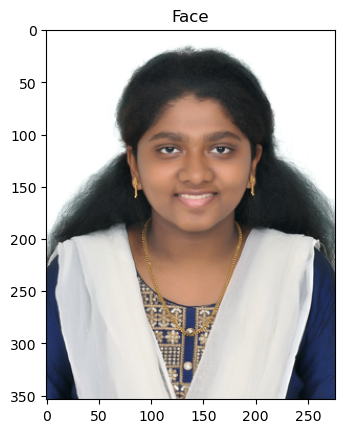

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Load face image
faceImage = cv2.imread("s.png")
plt.imshow(faceImage[:,:,::-1]); plt.title("Face")
print("Face shape:", faceImage.shape)

Glass shape: (236, 236, 3)


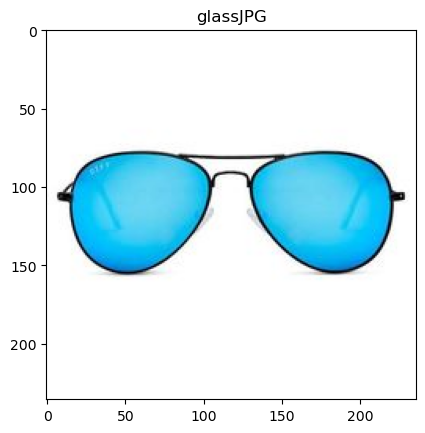

In [2]:
glassJPG = cv2.imread("glass.png")
plt.imshow(glassJPG[:,:,::-1]); plt.title("glassJPG")
print("Glass shape:", glassJPG.shape)

Text(0.5, 1.0, 'Sunglass Color channels')

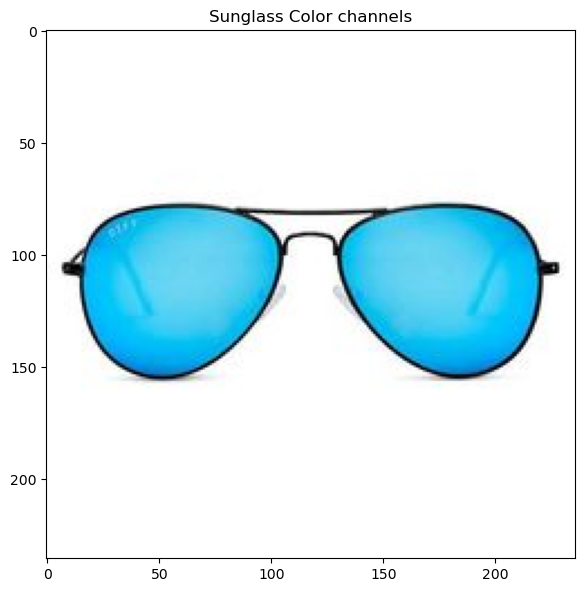

In [3]:
glassBGR = glassJPG[:,:,0:3]
glassGray = cv2.cvtColor(glassBGR, cv2.COLOR_BGR2GRAY)
_, glassMask1 = cv2.threshold(glassGray, 240, 255, cv2.THRESH_BINARY_INV)  # detect non-white

plt.figure(figsize=[15,15])
#Show sunglasses color channels
plt.subplot(121)
plt.imshow(glassBGR[:,:,::-1])  # BGR → RGB
plt.title('Sunglass Color channels')

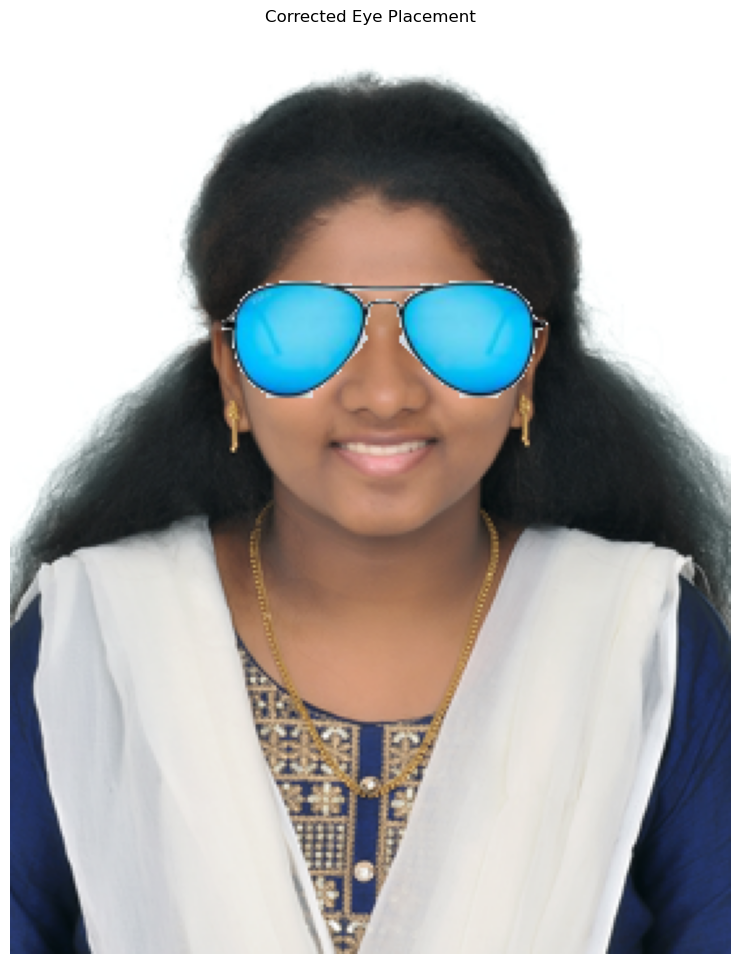

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load images
faceImage = cv2.imread("s.png")
# Ensure glass.png is in the same folder
glassPNG = cv2.imread("glass.png", cv2.IMREAD_UNCHANGED)

if faceImage is None or glassPNG is None:
    print("Error: Could not load images. Ensure 'h.jpg' and 'glass.png' are in the same folder.")
    exit()

face_h, face_w, _ = faceImage.shape

# 2. Resize glasses
# Scaled to 48% of the face width to cover both eyes correctly
new_w = int(face_w * 0.48) 
new_h = int(new_w * glassPNG.shape[0] / glassPNG.shape[1])
glass_resized = cv2.resize(glassPNG, (new_w, new_h), interpolation=cv2.INTER_AREA)

# 3. Extract Alpha and RGB
# glass.png MUST have 4 channels (BGRA) for this to work
if glass_resized.shape[2] == 4:
    glass_rgb = glass_resized[:, :, :3]
    alpha = glass_resized[:, :, 3] / 255.0
else:
    # Fallback: If it's a 3-channel image, we create a mask for dark pixels
    glass_rgb = glass_resized
    gray = cv2.cvtColor(glass_resized, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 230, 255, cv2.THRESH_BINARY_INV)
    alpha = mask / 255.0

# 4. PRECISE EYE POSITIONING (The Fix)
# For your specific h.jpg:
# x = 26% from left, y = 16% from top 
x = int(face_w * 0.28) 
y = int(face_h * 0.15) 

# 5. Define Region of Interest (ROI)
# We ensure the ROI stays within the image boundaries
y_end = min(y + new_h, face_h)
x_end = min(x + new_w, face_w)
roi = faceImage[y:y_end, x:x_end]

# Adjust glass/alpha dimensions if they were clipped by the boundary check
glass_rgb = glass_rgb[0:roi.shape[0], 0:roi.shape[1]]
alpha = alpha[0:roi.shape[0], 0:roi.shape[1]]

# 6. Smooth Blending
alpha_3d = alpha[:, :, np.newaxis]
# Formula: (Foreground * Alpha) + (Background * (1 - Alpha))
blended_roi = (glass_rgb * alpha_3d + roi * (1 - alpha_3d)).astype(np.uint8)

# 7. Place back and Display
faceImage[y:y_end, x:x_end] = blended_roi

plt.figure(figsize=(10, 12))
plt.imshow(cv2.cvtColor(faceImage, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Corrected Eye Placement")
plt.show()